# Issues when Looking at Trends in Hebrew Verbal Constructions over Time

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [58]:
import statsmodels.api as sm
from scipy.stats import binom, beta, spearmanr
from scipy.stats.distributions import chi2

## Intro

Looking at verbal constructions with the verb [יָדַע](https://www.blueletterbible.org/lexicon/h3045/kjv/wlc/0-1/)

Sources under discussion:
* John A. Cook, "Detecting Development in Biblical Hebrew Using Diachronic Typology" in Cynthia L. Miller-Naudé and Ziony Zevit (eds.), <i>Diachrony in Biblical Hebrew</i> (Winona Lake, IN: Eisenbrauns, 2012).
* Ronald Hendel and Jan Joosten, <i>How Old Is the Hebrew Bible?: A Linguistic, Textual, and Historical Study</i> (New Haven, CT: Yale University Press, 2018).

Plot taken from Hendel & Joosten (2018), p. 22; reproducing results from Cook (2012), p. 91.
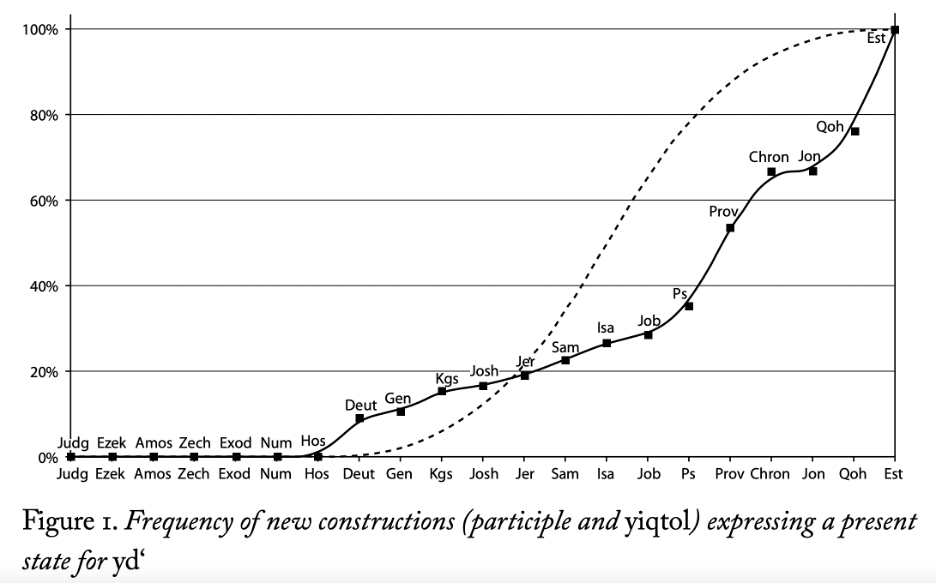

However, the trend that the author suggests as a function of temporal sequencing, as one form of the verbal construction came do dominate over another, is an artifact of sorting the sources by percentage of usage of the verbal form instead of temporal sequence. Notice, for example, that Amos, Ezekiel, and Zechariah are all grouped together, but these are pre-exilic, exilic, and post-exilic prophets. 

Second, there is not the actual S-curve the author suggests. In an S-curve, the growth in usage is exponentially upward, reaches a cusp and then exponentially slows down. In the results as sorted, the growth flattens and then goes up exponentially at the end. This looks more like a hyperbolic sine (sinh) curve, not a logistic curve (also called a sigmoid). The sinh function is the difference between an exponential increasing and an expoentially decreasing function divided by 2; the logistic curve is 1 divided by the sum of 1 and an exponentially decreasing function.

$sinh(x) = \frac{\exp(x) - \exp(-x)}{2}$

$sigmoid(x) = \frac{1}{1 + \exp(-x)}$

Next, it is demonstrated that the above curve, as well as the S-curve, can be produced with just randomly generated data when sorted by values instead of by date.

## Reproducing Results with Random Numbers

Original demonstration of an alleged temporal trend in verb usage in Hebrew by Cook (2012) 
is not valid, and it can be reproduced when there is no underlying trend. This section shows 
that the 'S curve' purported by Cook is produced by random numbers when sorted. 

In [59]:
# Uniform distribution of number of coin flips between 1 and 30
num_rolls_per_sim_list = np.random.randint(low=1, high=30, size=int(1e6))

In [60]:
# Plot sinh with distribution
in_array = np.linspace(-np.pi, np.pi, 1000)
out_array = np.sinh(in_array)

# Fitting limits of output to match next graph
out_array -= np.min(out_array)
out_array /= np.max(out_array)
in_array -= np.min(in_array)
in_array /= np.max(in_array)
in_array *= len(num_rolls_per_sim_list)

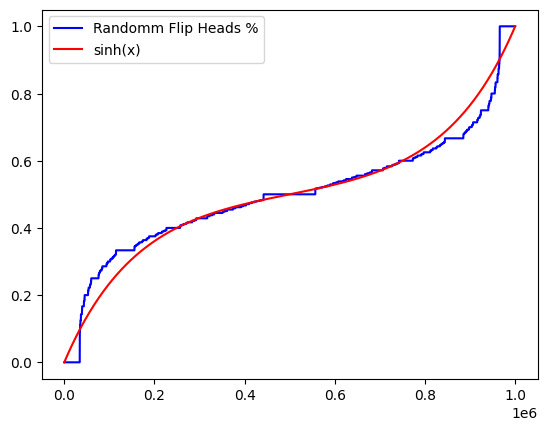

In [61]:
# Fair coin flips
plt.plot(np.arange(1,len(num_rolls_per_sim_list)+1), 
         np.sort(np.random.binomial(num_rolls_per_sim_list, 0.5)/num_rolls_per_sim_list), 
         color = 'b', 
         label = 'Randomm Flip Heads %')
plt.plot(in_array, out_array, color = 'red', label = 'sinh(x)')
plt.legend()
plt.show()
plt.close()

The match between the sinh curve (in red) and the random sorted data is strong, with the only divergences because of the floor and ceiling values (0 and 1). 

Next, the same sort of shape, but with the binomial probability set at the historical percentage of the time the verbal forms were utilized in the biblical record.

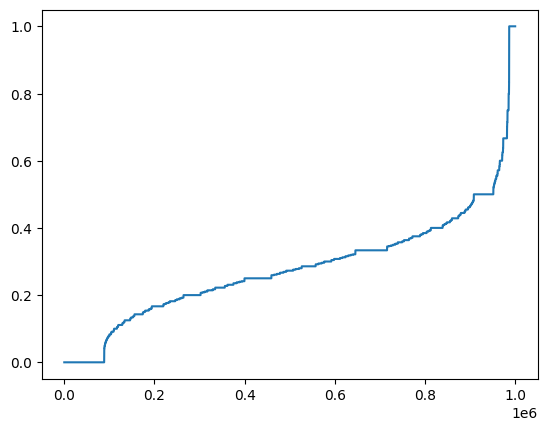

In [62]:
# Weighted coin, matching probability of getting usage of verb found in Cook (2012)
# Fraction of times verb usage was ~28%
plt.plot(np.arange(1,len(num_rolls_per_sim_list)+1), 
         np.sort(np.random.binomial(num_rolls_per_sim_list, 0.28)/num_rolls_per_sim_list), )
plt.show()
plt.close()

This curve looks even closer in form to the graph from Cook (2012). It even reproduces the floor effect seen in the sources that had 0 examples of the verbal form used.

The above curves are not S-curves as suggested by Cook, as they are more similar to hyperbolic sine
than the logit function. That S-curve is seen below.

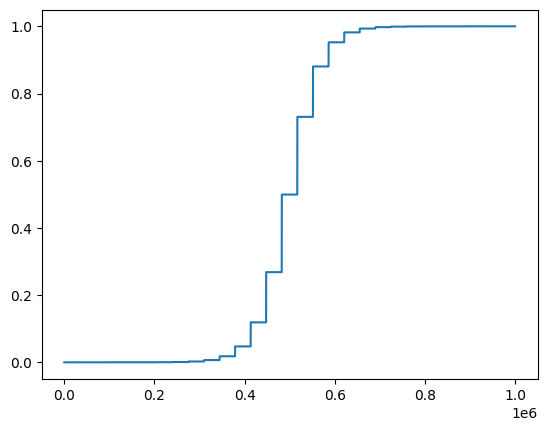

In [63]:
# Actual S-curve 
plt.plot(np.arange(1,len(num_rolls_per_sim_list)+1), 
         np.sort(1/(1+np.exp(-num_rolls_per_sim_list + np.mean(num_rolls_per_sim_list)))))
plt.show()
plt.close()

### Temporal Sequencing

The above curves exist simply by taking random numbers and sorting them from lowest to highest value, 
which means there is no way to find an underlying trend in that manner. Instead, to see if there is 
a temporal trend in verb usage, specifically for ידע, then the trend must be seen when results are sorted by time. This is done below, using dates of texts that are well-supported.

Note: originally, Cook did not split out Isaiah into its three parts, which were written at different 
times. Using his results, but splitting them into Proto-Isaiah, Deutero-Isaiah, and Tritio-Isaiah will 
produce more reliable results when considering the verb usage over time.

Similarly, several sources are not included because they are written over long spans of time (i.e., Psalms) 
or are of an unknown or debated date (i.e., Exodus). For the soruces with dates below, they are not exact, and moving their values a few years or even decades should have little difference to the overall results. One exception to consider, however, is Ecclesiastes/Qōheleṯ.

In [119]:
# Dictionary of prophets and approximate dates of writing
prophet_date_dict = {
                'ISA1': 700, 
                'ISA2': 550, 
                'ISA3': 400, 
                'EZEK': 570, 
                'AMOS': 760, 
                'ZECH': 510, # all counts found in 1 Zech
                'HOSEA': 725, 
                'JER': 590, 
                'ESTHER': 350, 
                'QOL': 330, # cusp of Persian/Hellenistic era
                'DAN': 167, 
                'JONAH': 400, 
                'MICAH': 720,  
                'CHRON': 350,
}

# Counts of using older and newer usages of verbal forms for ידע
verb_counts = {'ISA1': [4, 0], 
                'ISA2': [2, 3], 
                'ISA3': [5, 1], 
                'EZEK': [3, 0], 
                'AMOS': [3, 0], 
                'ZECH': [3, 0], # all counts found in 1 Zech
                'HOSEA': [4, 0], 
                'JER': [17, 4],
                'ESTHER': [0, 2], 
                'QOL': [5, 16], 
                'DAN': [1, 0], 
                'JONAH': [1, 2], 
                'MICAH': [1, 0], 
                'CHRON': [2, 4], 
              }

The dates for the sources are potentially debatable, especially Ecclesiastes, because it is unclear if it is from the Persian or the later Hellenistic era. This debate will have a small but potentially significant effect on the final results. It is also an important driver of results because Ecclesiastes uses the newer verbal form the most, compared to any other biblical writers.

In [107]:
# Counts from Cook (2012), p. 92
total_new_verbal_counts = 38+37
total_verbal_usages = 38+37+189
number_books = 39
number_sources = 17

### Functions

In [108]:
def laplace(s, ns):
    """
    Laplace Rule of Succession
    
    s: success count
    ns: not successful count
    
    returns: probability value
    """
    
    return ((s+1)/(s+ns+2))

In [109]:
def make_binomial(n, p):
    """
    Make a binomial PMF.
    
    n: number of spins
    p: probability of heads
    
    returns: Series representing a PMF
    """
    
    ks = np.arange(n+1)

    a = binom.pmf(ks, n, p)
    pmf_k = pd.Series(a, index=ks)
    return pmf_k

In [110]:
def get_post_prob(prior_succ, prior_tries, prior_sources, 
                  posterior_succ, posterior_tries, 
                  posterior_in_prior_counts = True, 
                  n_samples = 1000):
    """
    Get posterior probability based on a beta distribution prior and 
    binomial likelihood.
    
    prior_succ: number of successes/usages in prior dataset
    prior_tries: number of cases to check in prior dataset
    prior_sources: how many prior sources considered, used to average prior success rate
    posterior_succ: number of successes/usages in posterior dataset
    posterior_in_prior_counts: if posterior data counts were already among sources in 
            prior dataset; should be removed since posterior data should not be part of 
            prior data. If posterior dataset is small compared to prior, will not make 
            a significant difference. 
    n_samples: Number of data samplings; more for better granularity
    
    returns: most likely probability from posterior distribution
    """
    
    # Remove posterior data from prior dataset if former was included in latter
    if posterior_in_prior_counts:
        prior_sources -+ 1
        prior_succ -= posterior_succ
        prior_tries -= posterior_tries
    
    # Prior probability distribution
    # Beta(success count, failure count)
    # Counts divided by number of sources to get average counts per source
    xs = np.arange(n_samples+1) / n_samples
    beta_prior = beta.pdf(xs, 
                          prior_succ/prior_sources, 
                          (prior_tries-prior_succ)/prior_sources)
    beta_prior /= beta_prior.sum() # normalize results
    beta_prior = pd.Series(beta_prior, index=xs)
    
    # Binomial distribution for likelihood
    likelihood = binom.pmf(posterior_succ, posterior_tries, p=xs)
    
    # Posterior distribution
    posterior = beta_prior * likelihood
    posterior = pd.Series(posterior, index=xs)
    total = posterior.sum()
    posterior /= total # normalize results
    
    # Summary statistics of posterior distribution
    mean = np.sum(posterior.values*posterior.index)
    std = np.sqrt(np.sum((posterior.index - mean)**2 * posterior.values))
    most_prob = posterior.idxmax()
    
    return most_prob, mean, std, posterior

In [111]:
def wlinear_fit (x, y, w) :
    """
    Fit (x,y,w) to a linear function, using exact formulae for weighted linear
    regression. This code was translated from the GNU Scientific Library (GSL),
    it is an exact copy of the function gsl_fit_wlinear.
    
    """
    
    # Compute the weighted means and weighted deviations from the means
    # wm denotes a "weighted mean", wm(f) = (sum_i w_i f_i) / (sum_i w_i)
    W = np.sum(w)
    wm_x = np.average(x,weights=w)
    wm_y = np.average(y,weights=w)
    dx = x-wm_x
    dy = y-wm_y
    wm_dx2 = np.average(dx**2,weights=w)
    wm_dxdy = np.average(dx*dy,weights=w)
    # In terms of y = a + b x
    b = wm_dxdy / wm_dx2
    a = wm_y - wm_x*b
    cov_00 = (1.0/W) * (1.0 + wm_x**2/wm_dx2)
    cov_11 = 1.0 / (W*wm_dx2)
    cov_01 = -wm_x / (W*wm_dx2)
    # Compute chi^2 = \sum w_i (y_i - (a + b * x_i))^2
    chi2 = np.sum (w * (y-(a+b*x))**2)
    
    return a, b, cov_00, cov_11, cov_01, chi2

## Processing Data

Here we can consider the trend of verbal constructions by taking a Bayesian approach. Our hypothesis will account for the average historical use of the allegedly newer verbal construction. The null hypothesis in effect is that there is no secular change in the use of the verbal constructions, at least for the writing of the books of the Hebrew Bible. 

The prior is determined using the historical faction of the time the newer verbal construction is used. This is done by counting all uses of the examples of the older and newer forms of the verbal construction, and then those counts are divided by the number of sources counts exist in (namely, the number of books in the Bible). This count is imperfect since single books will have multiple authors (i.e., Isaiah, Psalms, Genesis). However, only 17 of the books even have either the older or newer verba construction. Thereforce, the use of the larger count of biblical books will make the priors weaker and drive the results less. Once these counts are averaged by the number of books, the values are put into a beta distribution--a distribution that gives the probability of probabilities. This is a standard function to generate prior probability distributions.

With the prior based on the historic average rate, then the data of each particular source is considered to see what is the expected probability of using the older or newer verbal construction. The counts of older and newer verbal usages will be inputed into the binomial distribution to get the likelihood of the results, given an underlying probability. With the prior multiplied by the likelihood, we get a new probability distribution. This will be the posterior probability of using the newer form of the verb in each source. The most probable value of the probability of using the newer verbal form is then recorded. From there, we will see if there is a trend.

In [112]:
x = []
y = []
z = []
b = []

data_df = pd.DataFrame(columns=['source', 'date', 'laplace', 'percent', 'bayes_mean', 'bayes_most_prob', 'bayes_std'])

for key in prophet_date_dict.keys():
    x.append(prophet_date_dict[key])
    tot = verb_counts[key][0] + verb_counts[key][1]
    s = tot - verb_counts[key][0]
    ns = verb_counts[key][0]
    y.append(laplace(s, ns))
    z.append(verb_counts[key][1]/tot)
    post_successes = verb_counts[key][1]
    post_total_uses = verb_counts[key][0] + verb_counts[key][1]
    most_prob, mean, sd, _ = get_post_prob(total_new_verbal_counts, total_verbal_usages, number_books, 
                                           post_successes, post_total_uses)
#     post_val = get_post_prob(total_new_verbal_counts, total_verbal_usages, number_books, 
#                              post_successes, post_total_uses)
    b.append(mean)
    data_df.loc[len(data_df)] = [key, 
                                 prophet_date_dict[key], 
                                 laplace(s, ns), 
                                 verb_counts[key][1]/tot, 
                                 most_prob, 
                                 mean, 
                                 sd]

In [113]:
# Sorted by increasing posterior probability of using newer verbal construction
data_df.sort_values(by='bayes_mean').reset_index(drop=True)

,source,date,laplace,percent,bayes_mean,bayes_most_prob,bayes_std
0,ISA1,700,0.023810,0.000000,0.021,0.042051,0.029349
1,HOSEA,725,0.166667,0.000000,0.107,0.180291,0.112548
2,EZEK,570,0.200000,0.000000,0.120,0.198415,0.121961
3,AMOS,760,0.200000,0.000000,0.120,0.198415,0.121961
4,ZECH,510,0.200000,0.000000,0.120,0.198415,0.121961
5,DAN,167,0.333333,0.000000,0.161,0.248346,0.146113
6,MICAH,720,0.333333,0.000000,0.161,0.248346,0.146113
7,ISA3,400,0.250000,0.166667,0.179,0.229675,0.113993
8,JER,590,0.217391,0.190476,0.191,0.213748,0.077156
9,JONAH,400,0.600000,0.666667,0.373,0.399471,0.149787


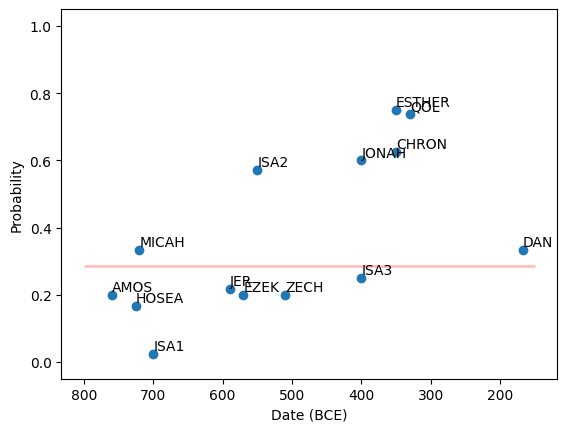

In [114]:
# Laplacian probs over time
prior = laplace(total_new_verbal_counts, total_verbal_usages - total_new_verbal_counts)

plt.scatter(x, y)
for i, txt in enumerate(prophet_date_dict.keys()):
    plt.annotate(txt, (x[i]+0.01, y[i]+0.01))
plt.ylim(-0.05, 1.05)
plt.hlines(y=prior, xmin=150, xmax=800, linewidth=2, color='r', alpha=0.25)
plt.gca().invert_xaxis()
plt.xlabel("Date (BCE)")
plt.ylabel("Probability")
plt.show()
plt.close()

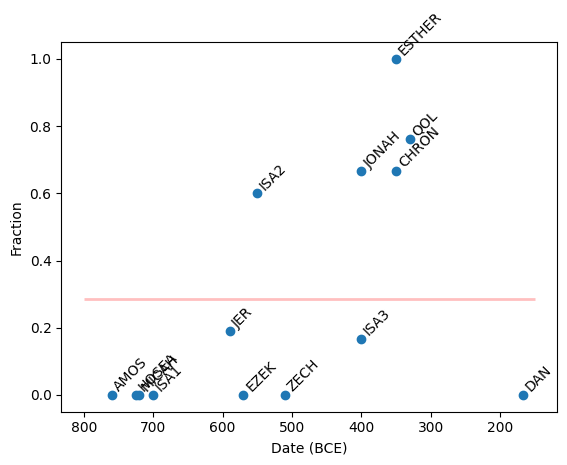

In [115]:
# Percentage of usage over time
plt.scatter(x, z)
for i, txt in enumerate(prophet_date_dict.keys()):
    plt.annotate(txt, (x[i]+0.01, z[i]+0.01), rotation=45)
plt.ylim(-0.05, 1.05)
plt.hlines(y=prior, xmin=150, xmax=800, linewidth=2, color='r', alpha=0.25)
plt.gca().invert_xaxis()
plt.xlabel("Date (BCE)")
plt.ylabel("Fraction")
plt.show()
plt.close()

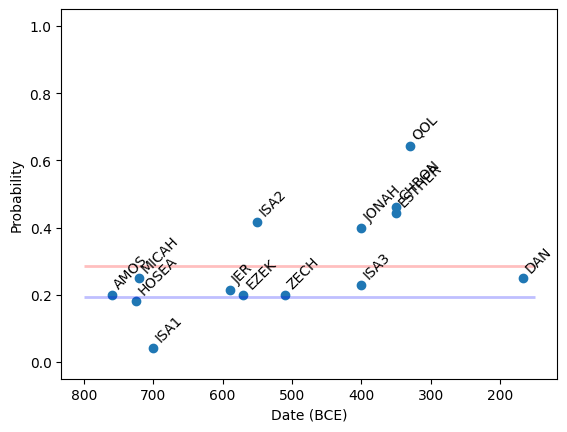

In [116]:
# Posterior probabilities over time
plt.scatter(x, b)
for i, txt in enumerate(prophet_date_dict.keys()):
    plt.annotate(txt, (x[i]+0.00, b[i]+0.02), rotation=45)
plt.hlines(y=prior, xmin=150, xmax=800, linewidth=2, color='r', alpha=0.25)
plt.hlines(y=get_post_prob(total_new_verbal_counts, total_verbal_usages, number_books, 0, 0)[0], 
           xmin=150, xmax=800, linewidth=2, color='b', alpha=0.25)
plt.ylim(-0.05, 1.05)
plt.gca().invert_xaxis()
plt.xlabel("Date (BCE)")
plt.ylabel("Probability")
plt.show()
plt.close()

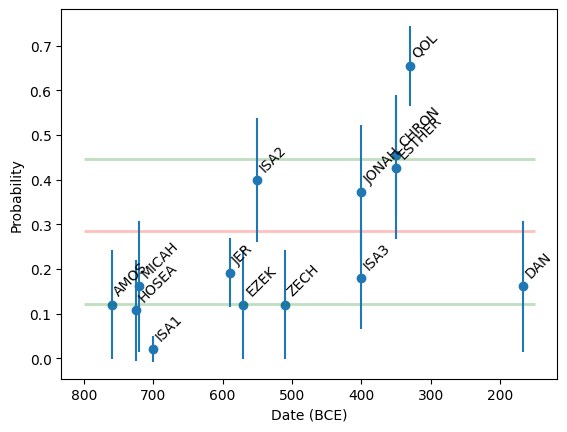

In [117]:
# Posterior probabilities over time
x = data_df['date']
b = data_df['bayes_mean']
errs = data_df['bayes_std']

prior_prob, prior_sd = get_post_prob(total_new_verbal_counts, total_verbal_usages, number_books, 0, 0)[1:3]

plt.scatter(x, b)
for i, txt in enumerate(prophet_date_dict.keys()):
    plt.annotate(txt, (x[i]+0.00, b[i]+0.02), rotation=45)
plt.hlines(y=prior_prob, 
           xmin=150, xmax=800, linewidth=2, color='r', alpha=0.25, label = 'prior probability')
plt.hlines(y=prior_prob + prior_sd, 
           xmin=150, xmax=800, linewidth=2, color='g', alpha=0.25,)
plt.hlines(y=prior_prob - prior_sd, 
           xmin=150, xmax=800, linewidth=2, color='g', alpha=0.25,)
#plt.ylim(-0.05, 1.05)
plt.errorbar(x, b, yerr=errs, linestyle="None")
plt.gca().invert_xaxis()
plt.xlabel("Date (BCE)")
plt.ylabel("Probability")
plt.show()
plt.close()

In [118]:
# Look at Spearman correlation, compare rank of values vs pure linear relationship
spearmanr(-data_df['date'], data_df['bayes_mean'])

SignificanceResult(statistic=np.float64(0.6799594557160809), pvalue=np.float64(0.007459725516320242))

In [77]:
spearmanr(-data_df['date'], data_df['bayes_mean'])[0]**2

nan

Looks like almost all of the correlation will exist because of Ecclesiastes/Qōheleṯ. This is not 
good, since the dating of Ecclesiastes is argued as either Persian Era or Hellenistic. If it is 
Persian (ca. 400 BCE), the trend is all but gone; if it is Hellenistic (ca. 200 BCE), then the 
trend might be statistically significant.

## Regression Analysis on Bayesian Prob Results

In [78]:
# Simple linear model
X2 = sm.add_constant(-x)
est = sm.OLS(b, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:             bayes_mean   R-squared:                         nan
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 21 Nov 2025   Prob (F-statistic):                nan
Time:                        14:09:23   Log-Likelihood:                    nan
No. Observations:                  14   AIC:                               nan
Df Residuals:                      12   BIC:                               nan
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const             nan        nan        nan        n

In [79]:
# Logistic regression model
logit_b = np.log(b / (1 - b))

X2 = sm.add_constant(-x)
est = sm.OLS(logit_b, X2)
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:             bayes_mean   R-squared:                         nan
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 21 Nov 2025   Prob (F-statistic):                nan
Time:                        14:09:23   Log-Likelihood:                    nan
No. Observations:                  14   AIC:                               nan
Df Residuals:                      12   BIC:                               nan
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const             nan        nan        nan        n

In [80]:
# Get probability of using newer verbal form by 1 CE (date = 0)
const = est2.params[0]
np.exp(const)/(1 + np.exp(const))

/var/folders/5p/ph3v1s590p18wh0s9jk1sk3c0000gn/T/ipykernel_91162/1387362941.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  const = est2.params[0]


np.float64(nan)

In [81]:
data_df['log_odds_mean'] = np.log(data_df['bayes_mean'] / (1 - data_df['bayes_mean']))

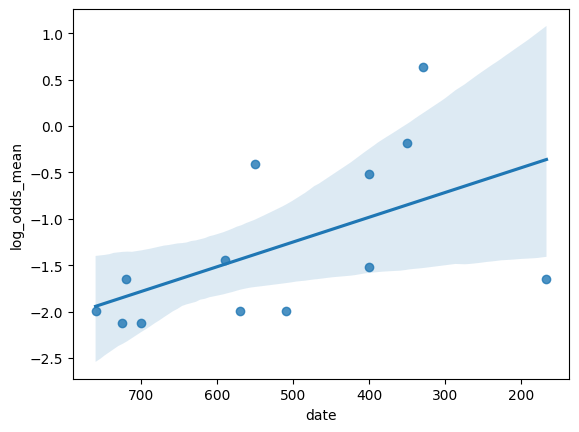

In [82]:
sns.regplot(x='date', y='log_odds_mean', data=data_df, logistic=False, ci=95, logx=False)
plt.gca().invert_xaxis()
plt.show()
plt.close()

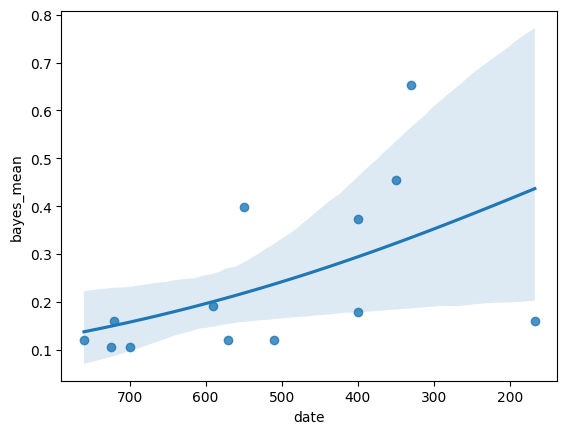

In [83]:
sns.regplot(x='date', y='bayes_mean', data=data_df, logistic=True, ci=95, logx=False)
plt.gca().invert_xaxis()
plt.show()
plt.close()

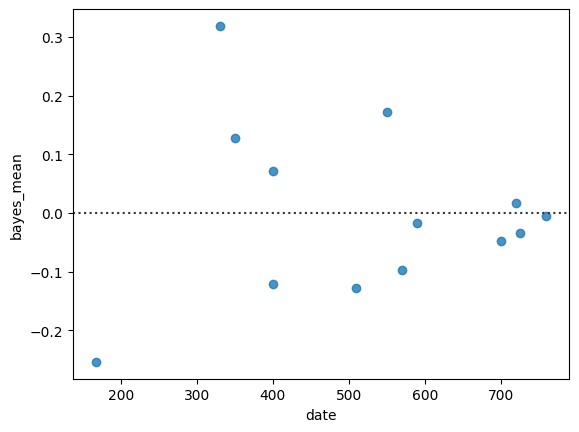

In [84]:
sns.residplot(data=data_df, x="date", y="bayes_mean")
plt.show()
plt.close()

### Weighted Linear Regression

Accounting for the uncertainties in the values, based on the standard deviations of the 
posterior probabilities.

Given the inputs of time, mean posterior probabilities, and the posterior standard deviations 
as the error ranges, the weighted linear fit output includes the vertical intercept (c), the 
slope (m), and the square root of the covariance terms 00 and 11 give the standard error of c 
and m. $\chi^2$ gives the goodness of fit, and comparing with a table of $\chi^2$ to p-values, 
one can see if the results are significant. This requires knowing the number of degrees of 
freedom, which in this case if the number of data points minus one. In this analysis, there are 
13 values, so 12 degrees of freedom; the minimum $\chi^2$ value needed for significance is 
approximately 21.1.

In [85]:
c0, m, cov_00, cov_11, cov_01, chi2_val = wlinear_fit(-x, b, 1/errs**2)

In [86]:
m, np.sqrt(cov_11), chi2_val

(np.float64(nan), np.float64(nan), np.float64(0.0))

In [87]:
chi2.sf(chi2_val, len(x) - 1)

np.float64(1.0)

In [88]:
m / np.sqrt(cov_11)

np.float64(nan)

In [89]:
c0, m, cov_00, cov_11, cov_01, chi2_val  = wlinear_fit(-x, np.log(b / (1 - b)), 1/np.log(errs / (1 - errs))**2)

In [90]:
m, np.sqrt(cov_11), chi2_val

(np.float64(nan), np.float64(nan), np.float64(0.0))

In [91]:
np.exp(m + np.sqrt(cov_11)), np.exp(m - np.sqrt(cov_11))

(np.float64(nan), np.float64(nan))

In [92]:
chi2.sf(chi2_val, len(x) - 1)

np.float64(1.0)

### Conclusions

There is a weak correlation between the posterior probabilities of the verbal usage discussed by Cook, 
but it does not pass the significance text (p > 0.05). This is true for both the simple linear model as 
well as the logistic model. The latter is closer to the hypothesis being considered (i.e., as time goes on, 
verbal usage goes from near 0% to near 100%), and its results are the most useful. Even ignoring the p 
value, the correlation is very weak, with the adjusted r-squared value < 0.25. 

Therefore, the evidence for a secular trend in the change in the verbal construction, suggested by Cook (2012), 
is not strong and is consistent with no trend at all. 